In [ ]:
# https://docs.ultralytics.com/guides/heatmaps/


import cv2

from ultralytics import solutions

cap = cv2.VideoCapture("path/to/video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("heatmap_output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# For object counting with heatmap, you can pass region points.
# region_points = [(20, 400), (1080, 400)]                                      # line points
# region_points = [(20, 400), (1080, 400), (1080, 360), (20, 360)]              # rectangle region
# region_points = [(20, 400), (1080, 400), (1080, 360), (20, 360), (20, 400)]   # polygon points

# Initialize heatmap object
heatmap = solutions.Heatmap(
    show=True,  # display the output
    model="yolo26n.pt",  # path to the YOLO26 model file
    colormap=cv2.COLORMAP_PARULA,  # colormap of heatmap
    # region=region_points,  # object counting with heatmaps, you can pass region_points
    # classes=[0, 2],  # generate heatmap for specific classes, e.g., person and car.
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()

    if not success:
        print("Video frame is empty or processing is complete.")
        break

    results = heatmap(im0)

    # print(results)  # access the output

    video_writer.write(results.plot_im)  # write the processed frame.

cap.release()
video_writer.release()
cv2.destroyAllWindows()  # destroy all opened windows

In [ ]:
import cv2

from ultralytics import solutions

cap = cv2.VideoCapture("path/to/video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("isegment_output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Initialize instance segmentation object
isegment = solutions.InstanceSegmentation(
    show=True,  # display the output
    model="yolo26n-seg.pt",  # model="yolo26n-seg.pt" for object segmentation using YOLO26.
    # classes=[0, 2],  # segment specific classes, e.g., person and car with the pretrained model.
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()

    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break

    results = isegment(im0)

    # print(results)  # access the output

    video_writer.write(results.plot_im)  # write the processed frame.

cap.release()
video_writer.release()
cv2.destroyAllWindows()  # destroy all opened windows

In [ ]:
# Model	size
# (pixels)	mAPval
# 50-95	mAPval
# 50-95(e2e)	Speed
# CPU ONNX
# (ms)	Speed
# T4 TensorRT10
# (ms)	params
# (M)	FLOPs
# (B)
# YOLO26n	640	40.9	40.1	38.9 ± 0.7	1.7 ± 0.0	2.4	5.4
# YOLO26s	640	48.6	47.8	87.2 ± 0.9	2.5 ± 0.0	9.5	20.7
# YOLO26m	640	53.1	52.5	220.0 ± 1.4	4.7 ± 0.1	20.4	68.2
# YOLO26l	640	55.0	54.4	286.2 ± 2.0	6.2 ± 0.2	24.8	86.4
# YOLO26x	640	57.5	56.9	525.8 ± 4.0	11.8 ± 0.2	55.7	193.9

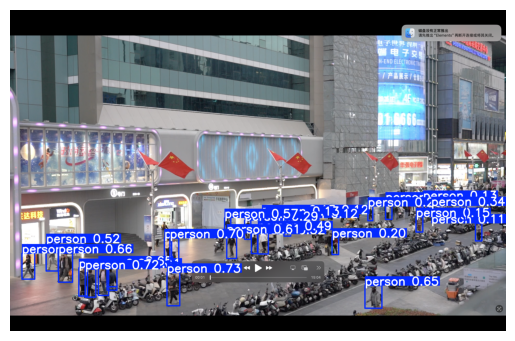

检测到 29 人


In [10]:
# detection
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Load a model
model = YOLO("yolo26n.pt")  # load an official model 
# model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model(
    "data/screenshot.png",
    conf=0.1,
    iou=0.5,
    classes=[0],   # 只检测人（COCO class 0）
    imgsz=1280,    # 更高分辨率
    verbose=False,
)



# Access the results
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box

for result in results:
    img = result.plot()  # 返回带检测框的BGR numpy数组
    plt.imshow(img[:, :, ::-1])  # BGR转RGB
    plt.axis("off")
    plt.show()

print(f"检测到 {len(results[0].boxes)} 人")


- yolo26l

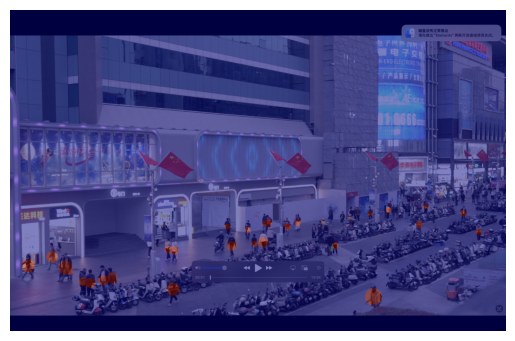

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

model = YOLO("yolo26n.pt")

results = model(
    "data/screenshot.png",
    conf=0.1,
    iou=0.5,
    classes=[0],   # 只检测人（COCO class 0）
    imgsz=1280,    # 更高分辨率，这个很有用
    verbose=False,
)


# 手动生成heatmap
heatmap = np.zeros(im0.shape[:2], dtype=np.float32)
for box in results[0].boxes.xyxy:
    x0, y0, x1, y1 = map(int, box)
    cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
    r = min(x1 - x0, y1 - y0) // 2
    cv2.circle(heatmap, (cx, cy), r, 1.0, -1)

# 上色叠加
heatmap_norm = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
colored = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)
output = cv2.addWeighted(im0, 0.5, colored, 0.5, 0)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26n.pt', 'classes': [0], 'show_conf': True, 'show_labels': True, 'region': None, 'colormap': 2, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.5, 'conf': 0.1, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'botsort.yaml', 'verbose': False, 'data': 'images'}


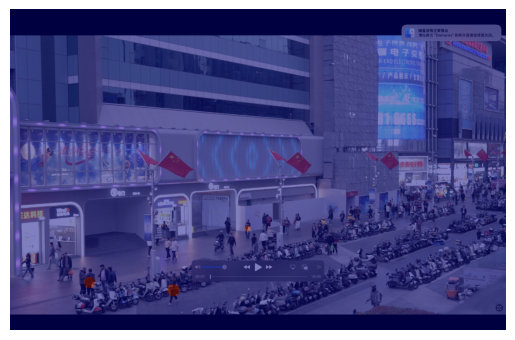

: 

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import solutions

im0 = cv2.imread("data/screenshot.png")

scale = 1280 / max(im0.shape[:2])  # 以长边为基准缩放到1280
new_w = int(im0.shape[1] * scale)
new_h = int(im0.shape[0] * scale)
im0_resized = cv2.resize(im0, (new_w, new_h))


heatmap = solutions.Heatmap(
    show=False,
    model="yolo26n.pt",
    colormap=cv2.COLORMAP_JET,
    conf=0.1,
    iou=0.5,
    classes=[0],
    verbose=False,

)

results = heatmap(im0)

cv2.imwrite("data/heatmap_output.jpg", results.plot_im)

plt.imshow(cv2.cvtColor(results.plot_im, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
import cv2
from ultralytics import solutions

# 读取单张图片
im0 = cv2.imread("data/screenshot.png")

# 初始化heatmap
# heatmap = solutions.Heatmap(
#     show=True,
#     model="yolo26m.pt",
#     colormap=cv2.COLORMAP_PARULA,
# )

heatmap = solutions.Heatmap(
    # show=True,
    model="yolo26n.pt",
    colormap=cv2.COLORMAP_JET,
    conf=0.01,
    iou=0.5,
    classes=[0],          # 只检测人
    verbose=False,
)


# 直接处理
results = heatmap(im0)

# 保存结果
cv2.imwrite("data/heatmap_output_n.jpg", results.plot_im)
cv2.waitKey(0)
cv2.destroyAllWindows()

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26n.pt', 'classes': [0], 'show_conf': True, 'show_labels': True, 'region': None, 'colormap': 2, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.5, 'conf': 0.01, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'botsort.yaml', 'verbose': False, 'data': 'images'}


In [ ]:
import cv2

from ultralytics import solutions

cap = cv2.VideoCapture("path/to/video.mp4")
heatmap = solutions.Heatmap(colormap=cv2.COLORMAP_PARULA, show=True, model="yolo26n.pt")

while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        break
    results = heatmap(im0)
cap.release()
cv2.destroyAllWindows()

In [ ]:
# https://universe.roboflow.com/yolo-ytzsf/find-people-from-sky